# Занятие 02. Регрессия по внешнему набору данных: Zenodo PMSM inverter fault diagnosis

## Теоретический блок

Регрессия (regression) - задача прогнозирования непрерывной величины.
В данном блокноте прогнозируется максимальная температура полумоста инвертора. Для
временных или профильных инженерных данных особенно важен способ проверки:
случайное перемешивание соседних точек может завысить качество модели.
Поэтому используется holdout-разбиение по группам, то есть часть профилей
полностью откладывается в тестовую выборку.

## Описание источника и учебная гипотеза

Набор содержит измерения инвертора постоянно-магнитной синхронной машины (Permanent Magnet Synchronous Motor, PMSM) в нормальном режиме и при отказах. Он полезен для связи анализа данных с диагностикой силовой электроники.

Структура данных: Feature-CSV содержит режимные признаки: прокси-момент, напряжение звена постоянного тока, ток и среднюю температуру. Diagnostics-CSV хранит максимальную температуру полумоста, код отказа FDD, фазные токи, мощности и дополнительные диагностические разности.

Особенность обработки: Код отказа и диагностические разности нельзя автоматически включать в базовую модель, поскольку они раскрывают исходную разметку или являются производными диагностическими величинами.

Учебная гипотеза занятия: строгий набор признаков должен давать
интерпретируемый, но не обязательно максимальный прогноз. Если качество резко
возрастает после добавления диагностических столбцов, это рассматривается как
признак возможной утечки данных, а не как автоматическое улучшение модели.

## Метрики регрессии

Средняя абсолютная ошибка (Mean Absolute Error, MAE) вычисляется как

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|.$$

Корень из средней квадратичной ошибки (Root Mean Squared Error, RMSE)
вычисляется как

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}.$$

Коэффициент детерминации (coefficient of determination, R2) определяется как

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}.$$

MAE и RMSE выражаются в единицах целевой переменной. R2 является безразмерной
метрикой и показывает, насколько модель лучше базового прогноза средним
значением.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/zenodo_pmsm_inverter_fault_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
TIME_KIND = "время измерения из исходного файла в условных секундах эксперимента"
DATASET_ID = "zenodo_pmsm_inverter_fault"
DATASET_TITLE = "Zenodo PMSM inverter fault diagnosis"
ALLOW_BASE_FALLBACK = False

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        if not ALLOW_BASE_FALLBACK:
            raise FileNotFoundError(
                "Не найдены подготовленные внешние CSV. Выполните "
                "`venv/bin/python scripts/prepare_external_datasets.py`. "
                "Для аварийной демонстрации можно вручную установить "
                "ALLOW_BASE_FALLBACK = True, но тогда выводы блокнота будут "
                "относиться к базовому синтетическому набору, а не к внешнему источнику."
            )
        print(
            "Предупреждение: используется базовый синтетический CSV. "
            "Содержательные выводы по внешнему источнику в этом режиме недействительны."
        )
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25, target_column=None):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    train_idx = data.index[~test_mask]
    test_idx = data.index[test_mask]

    if target_column is None or target_column not in data.columns or data[target_column].nunique() < 2:
        return train_idx, test_idx, test_groups

    def _has_two_classes(index):
        return data.loc[index, target_column].nunique() >= 2

    if _has_two_classes(train_idx) and _has_two_classes(test_idx):
        return train_idx, test_idx, test_groups

    selected_groups = []
    for class_value in sorted(data[target_column].dropna().unique()):
        class_groups = np.array(sorted(data.loc[data[target_column] == class_value, group_column].dropna().unique()))
        class_test_count = max(1, int(np.ceil(len(class_groups) * test_share)))
        selected_groups.extend(class_groups[-class_test_count:].tolist())
    test_groups = np.array(sorted(set(selected_groups)))
    test_mask = data[group_column].isin(test_groups)
    train_idx = data.index[~test_mask]
    test_idx = data.index[test_mask]
    if not (_has_two_classes(train_idx) and _has_two_classes(test_idx)):
        raise ValueError(
            "Групповое разбиение не содержит оба класса в обучающей и тестовой "
            "выборках. Проверьте profile_id или правило формирования is_allowed."
        )
    return train_idx, test_idx, test_groups


def validate_features(features, forbidden, context):
    leaked = set(features) & set(forbidden)
    if leaked:
        raise AssertionError(
            f"Обнаружена утечка данных в {context}: {sorted(leaked)}"
        )
    return list(features)


def existing_columns(data, columns):
    result = []
    for column in columns:
        if column in data.columns and column not in result:
            result.append(column)
    return result


def compact_numeric_profile(data, columns):
    selected = data[existing_columns(data, columns)].select_dtypes(include=[np.number])
    rows = []
    for column in selected.columns:
        series = selected[column]
        rows.append(
            dict(
                column=column,
                missing_count=int(series.isna().sum()),
                missing_share=float(series.isna().mean()),
                unique_count=int(series.nunique(dropna=True)),
                minimum=float(series.min()),
                q25=float(series.quantile(0.25)),
                median=float(series.median()),
                q75=float(series.quantile(0.75)),
                maximum=float(series.max()),
                mean=float(series.mean()),
                std=float(series.std()),
            )
        )
    return pd.DataFrame(rows).set_index("column")


def print_missing_interpretation(data):
    missing_share = data.isna().mean().sort_values(ascending=False)
    nonzero = missing_share[missing_share > 0]
    if nonzero.empty:
        print("Интерпретация: пропуски не обнаружены. Для учебной работы это означает, что можно сосредоточиться на диапазонах, группах и риске утечки данных.")
    else:
        print("Интерпретация: обнаружены пропуски. Перед моделированием необходимо выбрать способ обработки и объяснить его физический смысл.")
        print(nonzero.head(10).to_string())


def print_group_interpretation(data, group_column):
    if group_column not in data.columns:
        print("Групповой столбец отсутствует. Следует явно обосновать выбранный способ разбиения данных.")
        return
    group_counts = data[group_column].value_counts()
    print(f"Число групп: {group_counts.shape[0]}.")
    print(f"Минимальный размер группы: {group_counts.min()}.")
    print(f"Максимальный размер группы: {group_counts.max()}.")
    print(
        "Интерпретация: если наблюдения внутри одной группы близки по происхождению, "
        "то строки одной группы нельзя произвольно делить между обучением и тестом."
    )


def print_top_correlations(data, columns, target_column, top_n=5):
    candidate_columns = [column for column in columns if column != target_column] + [target_column]
    usable_columns = existing_columns(data, candidate_columns)
    if target_column not in usable_columns:
        print(f"Целевая переменная {target_column} отсутствует.")
        return pd.DataFrame()
    corr = data[usable_columns].corr(numeric_only=True)[target_column].drop(target_column, errors="ignore")
    result = corr.reindex(corr.abs().sort_values(ascending=False).index).head(top_n).to_frame("correlation")
    print(
        "Интерпретация: высокая корреляция показывает сильную линейную связь, "
        "но не доказывает причинность. Также необходимо проверить, не является ли "
        "признак производным от целевой переменной."
    )
    return result


def interpret_regression_metrics(metrics):
    best_model = metrics["R2"].idxmax()
    best_r2 = metrics.loc[best_model, "R2"]
    best_mae = metrics.loc[best_model, "MAE"]
    print(f"Лучшая модель по R2: {best_model}.")
    print(f"R2 = {best_r2:.4f}; MAE = {best_mae:.4f}.")
    print(
        "Интерпретация: MAE показывает средний модуль ошибки в единицах целевой "
        "переменной. R2 показывает долю объясненной дисперсии относительно "
        "модели среднего значения. Высокий R2 должен дополнительно проверяться "
        "на утечку данных и устойчивость к способу разбиения."
    )


def interpret_split_comparison(metrics):
    if {"group_holdout", "random_split"}.issubset(metrics.index):
        delta = metrics.loc["random_split", "R2"] - metrics.loc["group_holdout", "R2"] if "R2" in metrics.columns else np.nan
        print(f"Разница random_split - group_holdout по R2: {delta:.4f}.")
        print(
            "Интерпретация: если случайное разбиение существенно лучше группового, "
            "это может указывать на информационную близость соседних наблюдений и "
            "завышение качества при случайном перемешивании."
        )
    else:
        print("Сравнение разбиений недоступно.")


def interpret_classification_metrics(metrics):
    if "strict_decision_tree" in metrics.index:
        row = metrics.loc["strict_decision_tree"]
        print(f"Accuracy строгого дерева: {row['accuracy']:.4f}.")
        print(f"Recall недопустимого класса: {row['recall_not_allowed']:.4f}.")
        print(f"Доля ложных разрешений: {row['dangerous_false_allowed_rate']:.4f}.")
        print(
            "Интерпретация: для инженерной безопасности recall недопустимого класса "
            "и доля ложных разрешений важнее, чем одна общая accuracy."
        )


def interpret_depth_metrics(metrics):
    best_depth = metrics["f1_not_allowed"].idxmax()
    print(f"Наилучшая глубина по F1 недопустимого класса: {best_depth}.")
    print(
        "Интерпретация: рост глубины увеличивает гибкость дерева, но может привести "
        "к переобучению. Следует выбирать не максимальную глубину, а глубину, которая "
        "дает приемлемый баланс качества и интерпретируемости."
    )


def plot_missingness(data, title):
    missing_share = data.isna().mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.25 * len(missing_share))))
    ax.barh(missing_share.index[::-1], missing_share.values[::-1], color="#4c78a8")
    ax.set_xlabel("Доля пропусков")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_boxplots(data, columns, title):
    selected = existing_columns(data, columns)
    if not selected:
        print("Нет доступных столбцов для построения диаграмм размаха.")
        return
    fig, axes = plt.subplots(1, len(selected), figsize=(max(10, 2.2 * len(selected)), 4))
    axes = np.atleast_1d(axes)
    for ax, column in zip(axes, selected):
        ax.boxplot(data[column].dropna(), vert=True)
        ax.set_title(column, rotation=20)
        ax.set_ylabel("Значение")
    plt.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()


def plot_time_or_group_profile(data, value_column, title):
    if value_column not in data.columns:
        print(f"Столбец {value_column} отсутствует.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    if TIME_COLUMN in data.columns:
        sample = data.sort_values([GROUP_COLUMN, TIME_COLUMN]).head(800)
        axes[0].plot(sample[TIME_COLUMN], sample[value_column], marker=".", linestyle="none", alpha=0.55)
        axes[0].set_xlabel(f"{TIME_COLUMN}: {TIME_KIND}")
        axes[0].set_ylabel(value_column)
        axes[0].set_title("Фрагмент временного, порядкового или траекторного профиля")
    else:
        axes[0].set_axis_off()
    if GROUP_COLUMN in data.columns:
        group_summary = data.groupby(GROUP_COLUMN)[value_column].median().head(40)
        axes[1].bar(group_summary.index.astype(str), group_summary.values, color="#f58518")
        axes[1].set_xlabel(GROUP_COLUMN)
        axes[1].set_ylabel(f"Медиана {value_column}")
        axes[1].set_title("Медианное значение по группам")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].set_axis_off()
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


def role_table(feature_columns, diagnostic_columns, regression_target, classification_target):
    rows = []
    all_columns = list(feature_columns) + [column for column in diagnostic_columns if column not in feature_columns]
    for column in all_columns:
        if column == "sample_id":
            role = "служебный идентификатор"
        elif column in {GROUP_COLUMN, TIME_COLUMN}:
            role = "служебный или группировочный столбец"
        elif column == regression_target:
            role = "целевая переменная регрессии"
        elif column == classification_target:
            role = "целевая переменная классификации"
        elif column in feature_columns:
            role = "доступный столбец feature-CSV"
        else:
            role = "диагностический столбец diagnostics-CSV"
        rows.append(dict(column=column, role=role))
    return pd.DataFrame(rows)


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/zenodo_pmsm_inverter_fault_features.csv
Размер feature-таблицы: (10892, 8)


,sample_id,profile_id,time_index,torque_proxy_nm,voltage_v,current_a,temperature_c,is_allowed
0,1,1001,0.0,5.642229,21.994135,6.118761,11.430371,1
1,2,1001,0.1,5.587977,21.994135,6.126954,11.954090,1
2,3,1001,0.2,12.912023,21.994135,6.078809,11.430230,1
3,4,1001,0.3,9.042033,21.994135,6.039383,11.843363,1
4,5,1001,0.4,5.533724,17.106549,6.022350,11.320267,1


In [2]:
regression_features = ['torque_proxy_nm', 'voltage_v', 'current_a', 'temperature_c']
regression_target = 'max_bridge_temp_c'
forbidden_regression_features = set(['max_bridge_temp_c', 'T1', 'T2', 'T3', 'is_allowed'])
regression_features = validate_features(
    regression_features,
    forbidden_regression_features,
    "regression_features",
)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

model_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=regression_features + [regression_target]
).copy()
train_idx, test_idx, test_groups = group_holdout_split(model_df, GROUP_COLUMN, test_share=0.25)
X_train = model_df.loc[train_idx, regression_features]
X_test = model_df.loc[test_idx, regression_features]
y_train = model_df.loc[train_idx, regression_target]
y_test = model_df.loc[test_idx, regression_target]

print("Тестовые группы:", test_groups)
print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)


Тестовые группы: [8001 8002 8003 8004 8005 8006 8007 9001 9002 9003 9004 9005]
Обучающая выборка: (8123, 4)
Тестовая выборка: (2769, 4)


In [3]:
regression_design_table = pd.DataFrame(
    {
        "column": regression_features + [regression_target],
        "role": ["строгий признак"] * len(regression_features) + ["целевая переменная"],
    }
)
forbidden_table = pd.DataFrame(
    {
        "column": sorted(forbidden_regression_features),
        "role": "запрещено в строгой модели из-за риска утечки",
    }
)
pd.concat([regression_design_table, forbidden_table], ignore_index=True)


,column,role
0,torque_proxy_nm,строгий признак
1,voltage_v,строгий признак
2,current_a,строгий признак
3,temperature_c,строгий признак
4,max_bridge_temp_c,целевая переменная
5,T1,запрещено в строгой модели из-за риска утечки
6,T2,запрещено в строгой модели из-за риска утечки
7,T3,запрещено в строгой модели из-за риска утечки
8,is_allowed,запрещено в строгой модели из-за риска утечки
9,max_bridge_temp_c,запрещено в строгой модели из-за риска утечки


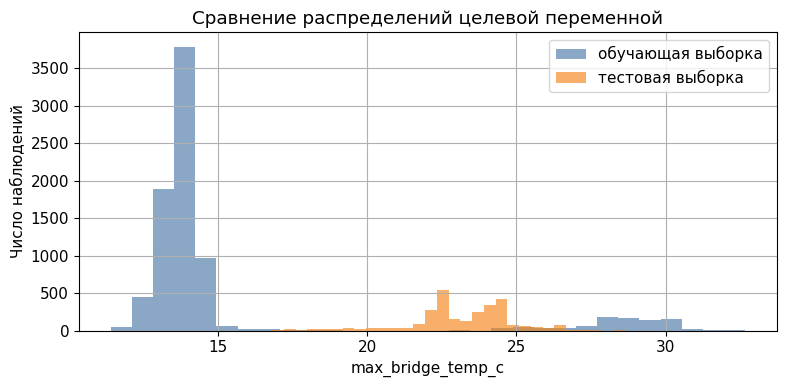

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train, bins=30, alpha=0.65, label="обучающая выборка", color="#4c78a8")
ax.hist(y_test, bins=30, alpha=0.65, label="тестовая выборка", color="#f58518")
ax.set_xlabel(regression_target)
ax.set_ylabel("Число наблюдений")
ax.set_title("Сравнение распределений целевой переменной")
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
target_correlations = (
    model_df[regression_features + [regression_target]]
    .corr(numeric_only=True)[regression_target]
    .drop(regression_target)
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .to_frame("correlation_with_target")
)
target_correlations


,correlation_with_target
temperature_c,0.946235
torque_proxy_nm,-0.238434
current_a,0.049276
voltage_v,0.048852


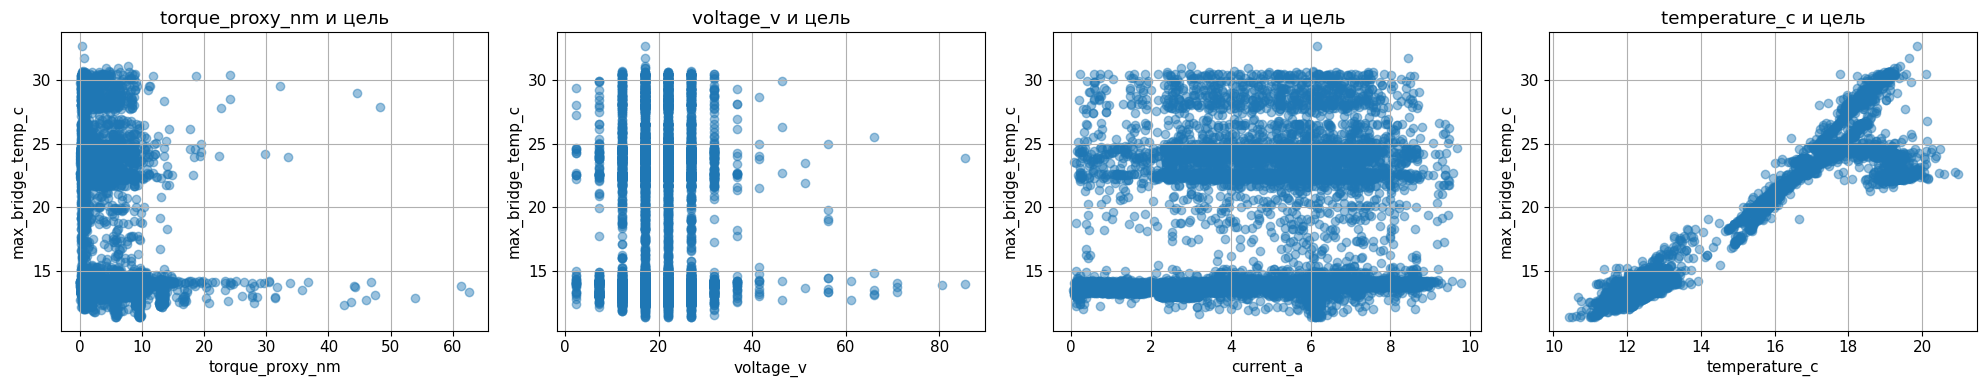

In [6]:
shown_features = regression_features[: min(4, len(regression_features))]
fig, axes = plt.subplots(1, len(shown_features), figsize=(5 * len(shown_features), 4))
axes = np.atleast_1d(axes)
for ax, column in zip(axes, shown_features):
    ax.scatter(model_df[column], model_df[regression_target], alpha=0.45)
    ax.set_xlabel(column)
    ax.set_ylabel(regression_target)
    ax.set_title(f"{column} и цель")
plt.tight_layout()
plt.show()


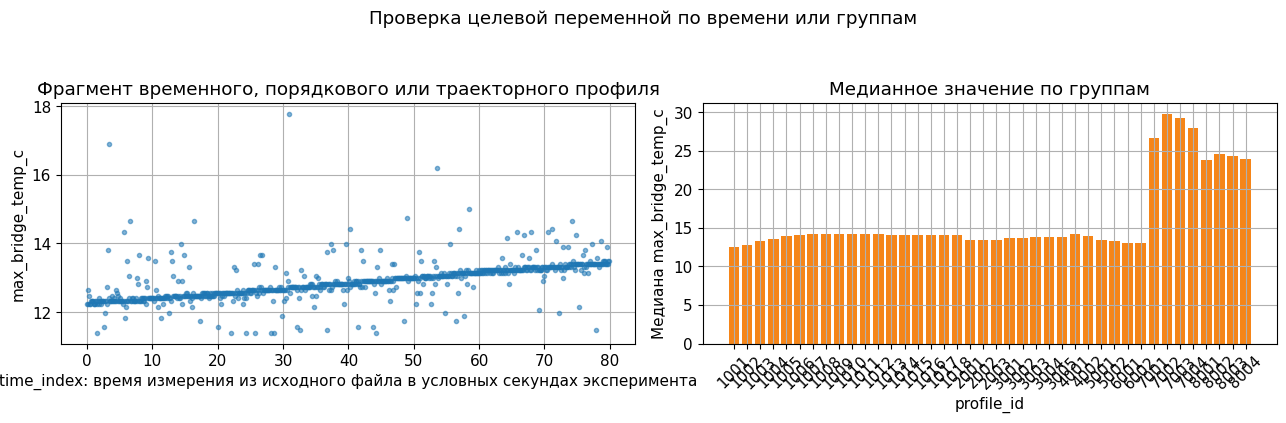

In [7]:
plot_time_or_group_profile(
    model_df,
    regression_target,
    "Проверка целевой переменной по времени или группам",
)


In [8]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }

models = {
    "mean_baseline": None,
    "linear_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "polynomial_ridge": Pipeline([
        ("input_scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
}

predictions = {}
rows = []
for name, model in models.items():
    if model is None:
        y_pred = np.full(len(y_test), y_train.mean())
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    predictions[name] = y_pred
    rows.append({"model": name, **regression_metrics(y_test, y_pred)})

metrics_df = pd.DataFrame(rows).set_index("model")
metrics_df


,MAE,RMSE,R2
model,,,
mean_baseline,7.896335,8.067968,-22.756252
linear_regression,4.349613,5.229736,-8.981805
polynomial_ridge,4.577121,6.006788,-12.168440


In [9]:
interpret_regression_metrics(metrics_df)


Лучшая модель по R2: linear_regression.
R2 = -8.9818; MAE = 4.3496.
Интерпретация: MAE показывает средний модуль ошибки в единицах целевой переменной. R2 показывает долю объясненной дисперсии относительно модели среднего значения. Высокий R2 должен дополнительно проверяться на утечку данных и устойчивость к способу разбиения.


In [10]:
linear_pipeline = models["linear_regression"]
linear_coefficients = pd.Series(
    linear_pipeline.named_steps["model"].coef_,
    index=regression_features,
    name="standardized_coefficient",
).sort_values(key=lambda series: series.abs(), ascending=False)
linear_coefficients.to_frame()


,standardized_coefficient
temperature_c,4.551690
current_a,0.333616
torque_proxy_nm,0.184531
voltage_v,0.057351


In [11]:
random_train_idx, random_test_idx = train_test_split(
    model_df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
)
random_model = Pipeline([
    ("input_scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("poly_scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])
random_model.fit(model_df.loc[random_train_idx, regression_features], model_df.loc[random_train_idx, regression_target])
random_pred = random_model.predict(model_df.loc[random_test_idx, regression_features])

split_comparison = pd.DataFrame(
    [
        {"split_type": "group_holdout", **regression_metrics(y_test, predictions["polynomial_ridge"])},
        {
            "split_type": "random_split",
            **regression_metrics(model_df.loc[random_test_idx, regression_target], random_pred),
        },
    ]
).set_index("split_type")
split_comparison


,MAE,RMSE,R2
split_type,,,
group_holdout,4.577121,6.006788,-12.16844
random_split,1.070853,1.576464,0.91148


In [12]:
interpret_split_comparison(split_comparison)


Разница random_split - group_holdout по R2: 13.0799.
Интерпретация: если случайное разбиение существенно лучше группового, это может указывать на информационную близость соседних наблюдений и завышение качества при случайном перемешивании.


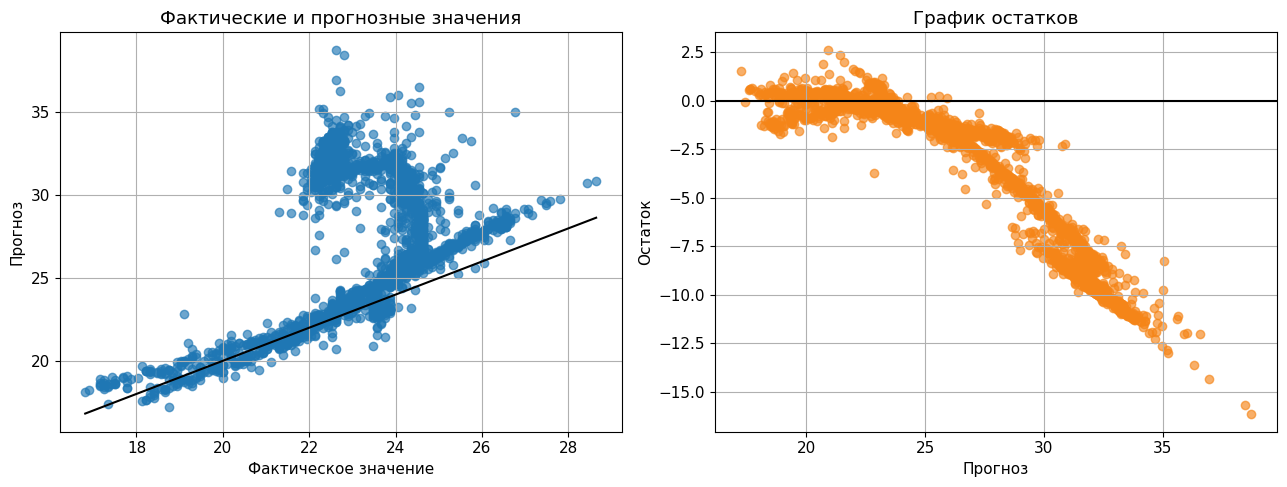

In [13]:
selected_pred = predictions["polynomial_ridge"]
residuals = y_test - selected_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, selected_pred, alpha=0.65)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black")
axes[0].set_xlabel("Фактическое значение")
axes[0].set_ylabel("Прогноз")
axes[0].set_title("Фактические и прогнозные значения")
axes[1].scatter(selected_pred, residuals, alpha=0.65, color="#f58518")
axes[1].axhline(0.0, color="black")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")
axes[1].set_title("График остатков")
plt.tight_layout()
plt.show()


In [14]:
residual_df = pd.DataFrame(
    {
        "sample_id": model_df.loc[y_test.index, "sample_id"],
        GROUP_COLUMN: model_df.loc[y_test.index, GROUP_COLUMN],
        "y_true": y_test,
        "y_pred": selected_pred,
        "residual": residuals,
        "abs_error": np.abs(residuals),
    }
)
residual_df["target_bin"] = pd.qcut(residual_df["y_true"], q=4, duplicates="drop")
error_by_target_bin = residual_df.groupby("target_bin", observed=True).agg(
    count=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    mean_residual=("residual", "mean"),
)
error_by_target_bin


,count,mean_abs_error,mean_residual
target_bin,,,
"(16.811999999999998, 22.423]",750,4.430160,-4.242279
"(22.423, 23.28]",637,6.816979,-6.793635
"(23.28, 24.347]",780,4.278797,-4.082498
"(24.347, 28.641]",602,2.776665,-2.774141


In [15]:
print(
    "Интерпретация: если средняя абсолютная ошибка заметно различается по "
    "квартилям целевой переменной, модель неодинаково точна в разных "
    "режимах работы объекта. Это важнее, чем одна усредненная метрика."
)


Интерпретация: если средняя абсолютная ошибка заметно различается по квартилям целевой переменной, модель неодинаково точна в разных режимах работы объекта. Это важнее, чем одна усредненная метрика.


In [16]:
group_error = (
    residual_df.groupby(GROUP_COLUMN)
    .agg(
        count=("abs_error", "size"),
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
    )
    .sort_values("mean_abs_error", ascending=False)
    .head(10)
)
group_error


,count,mean_abs_error,max_abs_error
profile_id,,,
8007,235,10.652350,16.128390
8006,250,9.795230,15.673584
8005,250,8.758385,12.864873
8004,250,7.897788,12.051408
8003,250,5.826315,8.699089
8002,250,3.373707,11.109947
9005,34,1.755397,2.451994
9004,250,1.653149,4.002188
8001,250,1.281350,5.932475


In [17]:
print(
    "Интерпретация: группы с наибольшей ошибкой следует проверить отдельно. "
    "Они могут соответствовать другому режиму испытаний, поездки или отказа."
)


Интерпретация: группы с наибольшей ошибкой следует проверить отдельно. Они могут соответствовать другому режиму испытаний, поездки или отказа.


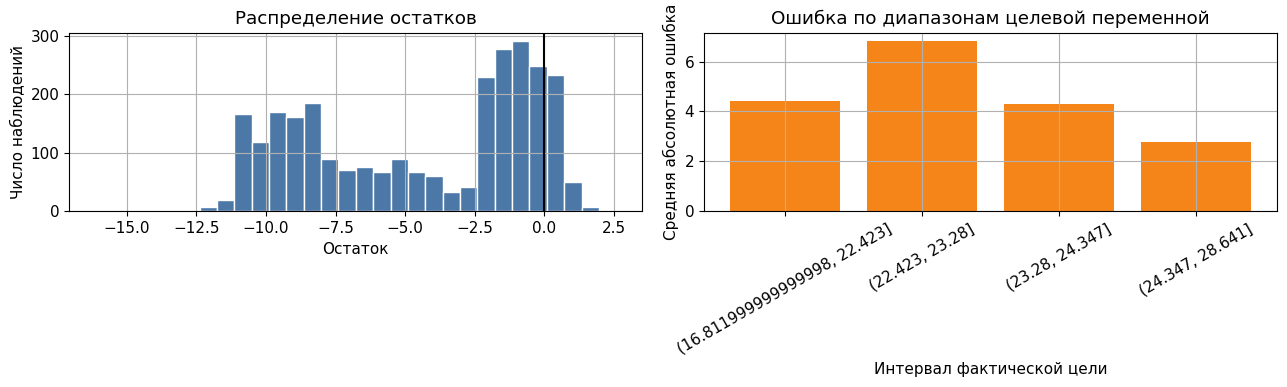

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residual_df["residual"], bins=30, color="#4c78a8", edgecolor="white")
axes[0].axvline(0.0, color="black")
axes[0].set_xlabel("Остаток")
axes[0].set_ylabel("Число наблюдений")
axes[0].set_title("Распределение остатков")
axes[1].bar(error_by_target_bin.index.astype(str), error_by_target_bin["mean_abs_error"], color="#f58518")
axes[1].set_xlabel("Интервал фактической цели")
axes[1].set_ylabel("Средняя абсолютная ошибка")
axes[1].set_title("Ошибка по диапазонам целевой переменной")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


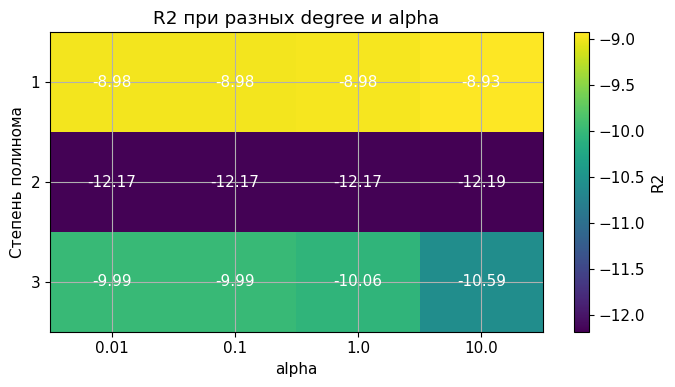

,degree,alpha,MAE,RMSE,R2
3,1,10.00,4.334343,5.214963,-8.925493
2,1,1.00,4.348083,5.228256,-8.976159
1,1,0.10,4.349460,5.229588,-8.981240
0,1,0.01,4.349597,5.229721,-8.981749
8,3,0.01,4.394983,5.486939,-9.987780
9,3,0.10,4.395410,5.488513,-9.994083
10,3,1.00,4.399625,5.503967,-10.056084
11,3,10.00,4.437793,5.635129,-10.589305
4,2,0.01,4.577264,6.006260,-12.166121
5,2,0.10,4.577251,6.006308,-12.166334


In [19]:
degrees = [1, 2, 3]
alphas = [0.01, 0.1, 1.0, 10.0]
grid_rows = []
for degree in degrees:
    for alpha in alphas:
        grid_model = Pipeline([
            ("input_scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("poly_scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha)),
        ])
        grid_model.fit(X_train, y_train)
        grid_pred = grid_model.predict(X_test)
        grid_rows.append(
            {
                "degree": degree,
                "alpha": alpha,
                **regression_metrics(y_test, grid_pred),
            }
        )

grid_metrics = pd.DataFrame(grid_rows)
grid_r2 = grid_metrics.pivot(index="degree", columns="alpha", values="R2")

fig, ax = plt.subplots(figsize=(7, 4))
image = ax.imshow(grid_r2.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(grid_r2.columns)))
ax.set_xticklabels(grid_r2.columns)
ax.set_yticks(range(len(grid_r2.index)))
ax.set_yticklabels(grid_r2.index)
ax.set_xlabel("alpha")
ax.set_ylabel("Степень полинома")
ax.set_title("R2 при разных degree и alpha")
fig.colorbar(image, ax=ax, label="R2")
for i in range(grid_r2.shape[0]):
    for j in range(grid_r2.shape[1]):
        ax.text(j, i, f"{grid_r2.iloc[i, j]:.2f}", ha="center", va="center", color="white")
plt.tight_layout()
plt.show()

grid_metrics.sort_values("R2", ascending=False).head(10)


In [20]:
best_grid_row = grid_metrics.sort_values("R2", ascending=False).iloc[0]
print(
    "Интерпретация сетки экспериментов: лучший вариант в этой сетке имеет "
    f"degree={int(best_grid_row['degree'])}, alpha={best_grid_row['alpha']} "
    f"и R2={best_grid_row['R2']:.4f}."
)
print(
    "Если увеличение степени полинома почти не повышает качество, более простая "
    "модель предпочтительнее, поскольку ее легче объяснить и труднее переобучить."
)


Интерпретация сетки экспериментов: лучший вариант в этой сетке имеет degree=1, alpha=10.0 и R2=-8.9255.
Если увеличение степени полинома почти не повышает качество, более простая модель предпочтительнее, поскольку ее легче объяснить и труднее переобучить.


## Демонстрация риска утечки данных

Ниже используется расширенный набор признаков, включающий диагностические или
расчетные столбцы. Если метрики резко улучшаются, результат нельзя считать
доказательством качества базовой модели: возможно, модель получила
информацию, недоступную в момент реального прогноза.


In [21]:
leakage_features = [column for column in ['torque_proxy_nm', 'voltage_v', 'current_a', 'temperature_c', 'T1', 'T2', 'T3'] if column in full_df.columns]
leakage_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=leakage_features + [regression_target]
).copy()
if len(leakage_features) >= 2 and len(leakage_df) > 20:
    train_idx_l, test_idx_l, _ = group_holdout_split(leakage_df, GROUP_COLUMN, test_share=0.25)
    leakage_model = Pipeline([
        ("input_scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])
    leakage_model.fit(leakage_df.loc[train_idx_l, leakage_features], leakage_df.loc[train_idx_l, regression_target])
    leakage_pred = leakage_model.predict(leakage_df.loc[test_idx_l, leakage_features])
    leakage_metrics = pd.Series(
        regression_metrics(leakage_df.loc[test_idx_l, regression_target], leakage_pred),
        name="leakage_demo",
    )
else:
    leakage_metrics = pd.Series(dtype=float, name="leakage_demo")
leakage_metrics.to_frame("value")


,value
MAE,3.895432
RMSE,4.766874
R2,-7.293103


In [22]:
if not leakage_metrics.empty:
    strict_r2 = metrics_df.loc["polynomial_ridge", "R2"]
    leakage_r2 = leakage_metrics.get("R2", np.nan)
    print(f"R2 строгой модели: {strict_r2:.4f}.")
    print(f"R2 демонстрации утечки: {leakage_r2:.4f}.")
    print(
        "Интерпретация: резкий рост качества после добавления диагностических "
        "столбцов не следует трактовать как инженерный успех. Сначала нужно "
        "проверить, доступны ли эти признаки в момент реального прогноза."
    )


R2 строгой модели: -12.1684.
R2 демонстрации утечки: -7.2931.
Интерпретация: резкий рост качества после добавления диагностических столбцов не следует трактовать как инженерный успех. Сначала нужно проверить, доступны ли эти признаки в момент реального прогноза.


In [23]:
experiment_degree = 2
experiment_alpha = 1.0
experiment_model = Pipeline([
    ("input_scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=experiment_degree, include_bias=False)),
    ("poly_scaler", StandardScaler()),
    ("model", Ridge(alpha=experiment_alpha)),
])
experiment_model.fit(X_train, y_train)
experiment_pred = experiment_model.predict(X_test)
pd.Series(regression_metrics(y_test, experiment_pred), name="experiment")


MAE      4.577121
RMSE     6.006788
R2     -12.168440
Name: experiment, dtype: float64

## Интерпретация экспериментов

Сравнение group holdout и random split показывает, насколько оценка качества
зависит от процедуры разбиения. Если случайное разбиение дает заметно более
высокий результат, это может означать, что соседние или однородные фрагменты
попадают одновременно в обучение и тест. Анализ остатков по диапазонам цели
показывает, в каких режимах модель ошибается сильнее. Сетка `degree` и
`alpha` демонстрирует компромисс между гибкостью модели и регуляризацией.


## Типовые ошибки интерпретации

1. Сравнивать модели только по R2 и не анализировать MAE, RMSE и остатки.
2. Считать случайное разбиение всегда корректным. Для временных и профильных
   данных оно может завышать качество.
3. Использовать диагностические столбцы как обычные признаки без проверки
   доступности в момент прогноза.
4. Выбирать наиболее сложную модель только потому, что она дала немного
   больший R2.

## Контрольные вопросы и мини-задания

1. Почему выбранная целевая переменная является непрерывной величиной?
2. Чем MAE отличается от RMSE с точки зрения чувствительности к крупным
   ошибкам?
3. Почему `group_holdout` может быть строже, чем `random_split`?
4. Измените `experiment_degree` и `experiment_alpha`, затем объясните, как
   изменились MAE, RMSE и R2.
5. Найдите группу с наибольшей ошибкой и сформулируйте инженерную гипотезу,
   почему она сложна для модели.


## Задание

1. Укажите целевую переменную и строгий набор признаков.
2. Объясните, почему применено разбиение по профилям или датам.
3. Сравните базовую модель, линейную регрессию и полиномиальную гребневую
   регрессию (Ridge regression).
4. Постройте график остатков и объясните систематические ошибки.
5. Отдельно опишите демонстрацию утечки данных.
